In [1]:
# DesignGym 2.0 — SFT Warm Start
#
# Goal:
# Fine-tune Qwen2.5-0.5B-Instruct with LoRA so it learns the DesignGym action language:
# brief + phase + layout metrics -> valid JSON action.
#
# This is not the final RL run.
# This SFT adapter will be used as the warm start for GRPO.

In [2]:
!nvidia-smi

Sat Apr 25 18:46:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Install dependencies

In [3]:
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps trl peft accelerate bitsandbytes datasets transformers matplotlib pandas huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Mount Google Drive

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Create a project folder:

In [5]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/DesignGym2")
DATA_DIR = PROJECT_DIR / "data" / "sft"
RUN_DIR = PROJECT_DIR / "runs" / "sft_qwen05"
PLOT_DIR = RUN_DIR / "plots"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RUN_DIR:", RUN_DIR)

PROJECT_DIR: /content/drive/MyDrive/DesignGym2
DATA_DIR: /content/drive/MyDrive/DesignGym2/data/sft
RUN_DIR: /content/drive/MyDrive/DesignGym2/runs/sft_qwen05


In [7]:
from google.colab import files
uploaded = files.upload()

Saving designgym2_sft_eval.jsonl to designgym2_sft_eval.jsonl
Saving designgym2_sft_train.jsonl to designgym2_sft_train (1).jsonl


In [8]:
import shutil
from pathlib import Path

for name in ["designgym2_sft_train.jsonl", "designgym2_sft_eval.jsonl"]:
    src = Path("/content") / name
    dst = DATA_DIR / name
    if src.exists():
        shutil.copy(src, dst)
        print("Copied:", dst)
    else:
        print("Missing:", src)

Copied: /content/drive/MyDrive/DesignGym2/data/sft/designgym2_sft_train.jsonl
Copied: /content/drive/MyDrive/DesignGym2/data/sft/designgym2_sft_eval.jsonl


Verify dataset

In [9]:
import json
from collections import Counter
from pathlib import Path

train_path = DATA_DIR / "designgym2_sft_train.jsonl"
eval_path = DATA_DIR / "designgym2_sft_eval.jsonl"

def inspect_jsonl(path):
    total = 0
    bad_json = 0
    actions = Counter()

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            total += 1
            text = row["messages"][-1]["content"]
            try:
                action = json.loads(text)
                actions[action.get("action_type", "missing")] += 1
            except Exception:
                bad_json += 1

    return total, bad_json, actions

train_total, train_bad, train_actions = inspect_jsonl(train_path)
eval_total, eval_bad, eval_actions = inspect_jsonl(eval_path)

print("train_total:", train_total, "train_bad_json:", train_bad)
print("eval_total:", eval_total, "eval_bad_json:", eval_bad)
print("train_actions:", train_actions)

train_total: 3898 train_bad_json: 0
eval_total: 434 eval_bad_json: 0
train_actions: Counter({'promote': 1044, 'anchor_to_region': 1004, 'resize': 671, 'apply_template': 403, 'reflow_group': 302, 'align': 233, 'move': 184, 'finalize': 57})


# action distribution chart

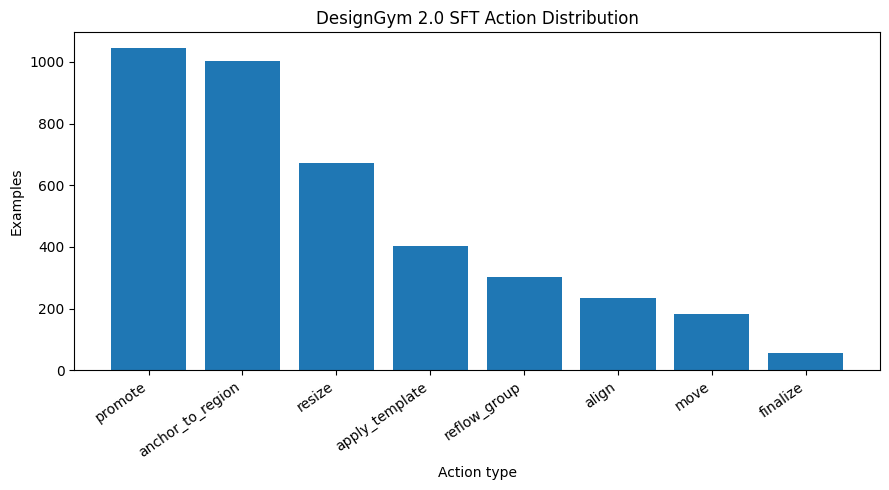

Saved: /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/plots/sft_action_distribution.png


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

df_actions = pd.DataFrame(
    [{"action_type": k, "count": v} for k, v in train_actions.items()]
).sort_values("count", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(df_actions["action_type"], df_actions["count"])
plt.title("DesignGym 2.0 SFT Action Distribution")
plt.xlabel("Action type")
plt.ylabel("Examples")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

action_plot_path = PLOT_DIR / "sft_action_distribution.png"
plt.savefig(action_plot_path, dpi=160)
plt.show()

print("Saved:", action_plot_path)

# Load dataset

In [11]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files={
        "train": str(train_path),
        "eval": str(eval_path),
    },
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating eval split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages', 'task_id', 'episode_seed', 'episode_index', 'step_index', 'expert_action', 'reward_after', 'score_after', 'instruction_score_after', 'phase_after'],
        num_rows: 3898
    })
    eval: Dataset({
        features: ['messages', 'task_id', 'episode_seed', 'episode_index', 'step_index', 'expert_action', 'reward_after', 'score_after', 'instruction_score_after', 'phase_after'],
        num_rows: 434
    })
})

Load Qwen2.5-0.5B with Unsloth LoRA

In [12]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 4096
dtype = None
load_in_4bit = True

model_name = "unsloth/Qwen2.5-0.5B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.


# Convert chat messages into training text

In [13]:
def formatting_prompts_func(examples):
    texts = []
    for messages in examples["messages"]:
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        texts.append(text)
    return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched=True)

print(dataset["train"][0]["text"][:1500])

Map:   0%|          | 0/3898 [00:00<?, ? examples/s]

Map:   0%|          | 0/434 [00:00<?, ? examples/s]

<|im_start|>system
You are a long-horizon spatial layout design agent. You receive a design brief, current phase, layout state, metrics, and feedback. Output exactly one valid minified JSON action object and nothing else.<|im_end|>
<|im_start|>user
Choose the next best layout edit.
Output only one valid minified JSON action object.

STATE:
{"allowed_actions": ["move", "resize", "align", "distribute", "promote", "reflow_group"], "best_score_so_far": 0.7928, "brief": {"brief_id": "luxury_event_poster", "domain": "graphic_layout", "preferences": {"cta_visibility": "high", "hierarchy": "strong", "whitespace": "high"}, "primary_goal": "Make the title and hero image dominant while keeping the CTA visible.", "required_regions": {"cta": "safe_lower_right", "hero_image": "hero_center", "logo": "top_right", "subtitle": "top_band", "title": "top_band"}, "style": "luxury_minimal"}, "critic_feedback": ["Spacing rhythm is weak; align or distribute related elements."], "current_score": 0.7928, "focus

Estimate token length

In [14]:
import numpy as np

def token_len(example):
    return {"n_tokens": len(tokenizer(example["text"], add_special_tokens=False)["input_ids"])}

length_sample = dataset["train"].select(range(min(300, len(dataset["train"]))))
length_sample = length_sample.map(token_len)

lengths = length_sample["n_tokens"]
print("min:", min(lengths))
print("mean:", round(float(np.mean(lengths)), 1))
print("p95:", round(float(np.percentile(lengths, 95)), 1))
print("max:", max(lengths))

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

min: 876
mean: 969.2
p95: 1012.0
max: 1023


# Train SFT

In [15]:
from trl import SFTTrainer
from transformers import TrainingArguments
import torch

output_dir = str(RUN_DIR / "trainer_output")

training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    warmup_steps=20,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    seed=42,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["eval"],
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    args=training_args,
)

train_result = trainer.train()
print(train_result)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/3898 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/434 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,898 | Num Epochs = 2 | Total steps = 488
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
50,0.232789,0.211387
100,0.153302,0.142692
150,0.119170,0.118213
200,0.100505,0.094357
250,0.070719,0.084671
300,0.078120,0.073659
350,0.078781,0.068911
400,0.060041,0.065454
450,0.065370,0.063781
488,0.063264,0.063630


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

TrainOutput(global_step=488, training_loss=0.18932587970964243, metrics={'train_runtime': 3090.3565, 'train_samples_per_second': 2.523, 'train_steps_per_second': 0.158, 'total_flos': 1.70325453570048e+16, 'train_loss': 0.18932587970964243, 'epoch': 2.0})


# Save LoRA adapter to Google Drive

In [16]:
adapter_dir = RUN_DIR / "designgym2_sft_qwen05_adapter"

model.save_pretrained(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))

print("Saved adapter to:", adapter_dir)

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/designgym2_sft_qwen05_adapter/tokenizer_config.json.


Saved adapter to: /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/designgym2_sft_qwen05_adapter


In [17]:
import shutil

zip_base = str(RUN_DIR / "designgym2_sft_qwen05_adapter")
zip_path = shutil.make_archive(zip_base, "zip", root_dir=str(adapter_dir))

print("Zipped adapter:", zip_path)

Zipped adapter: /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/designgym2_sft_qwen05_adapter.zip


In [18]:
from google.colab import files
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Training and eval loss

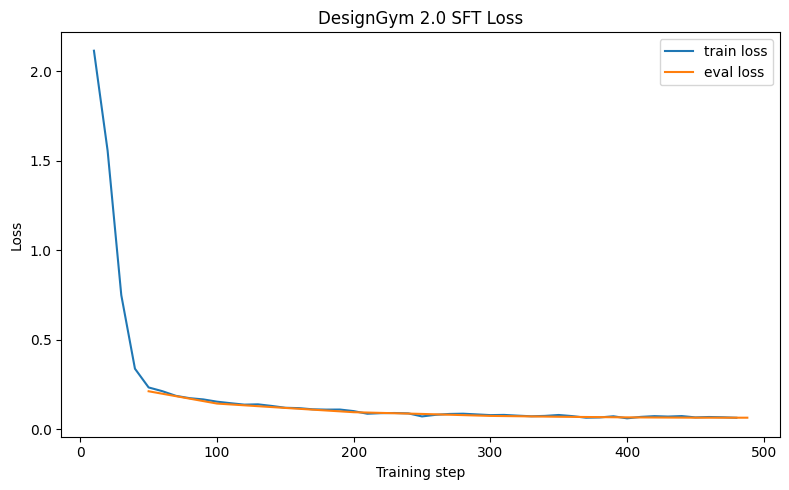

Saved: /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/plots/sft_loss_curve.png
Saved log: /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/trainer_log_history.json


In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

log_path = RUN_DIR / "trainer_log_history.json"
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(log_history, f, indent=2)

train_logs = [
    x for x in log_history
    if "loss" in x and "eval_loss" not in x
]
eval_logs = [
    x for x in log_history
    if "eval_loss" in x
]

plt.figure(figsize=(8, 5))

if train_logs:
    plt.plot(
        [x["step"] for x in train_logs],
        [x["loss"] for x in train_logs],
        label="train loss",
    )

if eval_logs:
    plt.plot(
        [x["step"] for x in eval_logs],
        [x["eval_loss"] for x in eval_logs],
        label="eval loss",
    )

plt.title("DesignGym 2.0 SFT Loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_plot_path = PLOT_DIR / "sft_loss_curve.png"
plt.savefig(loss_plot_path, dpi=160)
plt.show()

print("Saved:", loss_plot_path)
print("Saved log:", log_path)

JSON validity on eval prompts

In [20]:
from unsloth import FastLanguageModel
import json
import re
from collections import Counter
from tqdm.auto import tqdm

FastLanguageModel.for_inference(model)

def extract_json_object(text):
    # Try direct parse first.
    text = text.strip()
    try:
        return json.loads(text), text
    except Exception:
        pass

    # Fallback: find first {...}.
    match = re.search(r"\{.*?\}", text, flags=re.DOTALL)
    if not match:
        return None, text

    candidate = match.group(0)
    try:
        return json.loads(candidate), candidate
    except Exception:
        return None, text

def build_eval_prompt(row):
    messages = row["messages"][:2]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

eval_subset = dataset["eval"].select(range(min(100, len(dataset["eval"]))))

rows = []
valid_json = 0
valid_action = 0
action_counts = Counter()

allowed_action_types = {
    "apply_template",
    "anchor_to_region",
    "resize",
    "move",
    "align",
    "distribute",
    "promote",
    "reflow_group",
    "finalize",
}

for i, row in enumerate(tqdm(eval_subset)):
    prompt = build_eval_prompt(row)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=96,
        temperature=0.0,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated = full_text[len(tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=True)):].strip()

    parsed, extracted = extract_json_object(generated)

    is_json = parsed is not None
    is_action = bool(is_json and parsed.get("action_type") in allowed_action_types)

    if is_json:
        valid_json += 1
    if is_action:
        valid_action += 1
        action_counts[parsed["action_type"]] += 1

    rows.append({
        "index": i,
        "target": row["messages"][-1]["content"],
        "generated": generated,
        "extracted": extracted,
        "valid_json": is_json,
        "valid_action": is_action,
        "action_type": parsed.get("action_type") if parsed else None,
    })

valid_json_rate = valid_json / len(eval_subset)
valid_action_rate = valid_action / len(eval_subset)

print("valid_json_rate:", valid_json_rate)
print("valid_action_rate:", valid_action_rate)
print("generated_action_counts:", action_counts)

  0%|          | 0/100 [00:00<?, ?it/s]

Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

valid_json_rate: 1.0
valid_action_rate: 1.0
generated_action_counts: Counter({'anchor_to_region': 40, 'promote': 24, 'resize': 23, 'apply_template': 5, 'finalize': 4, 'reflow_group': 4})


# SFT evaluation results

In [21]:
eval_rows_path = RUN_DIR / "sft_eval_generations.jsonl"

with open(eval_rows_path, "w", encoding="utf-8") as f:
    for row in rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

summary = {
    "model": model_name,
    "train_examples": len(dataset["train"]),
    "eval_examples": len(dataset["eval"]),
    "eval_subset": len(eval_subset),
    "valid_json_rate": valid_json_rate,
    "valid_action_rate": valid_action_rate,
    "generated_action_counts": dict(action_counts),
    "adapter_dir": str(adapter_dir),
}

summary_path = RUN_DIR / "sft_eval_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

summary

{'model': 'unsloth/Qwen2.5-0.5B-Instruct',
 'train_examples': 3898,
 'eval_examples': 434,
 'eval_subset': 100,
 'valid_json_rate': 1.0,
 'valid_action_rate': 1.0,
 'generated_action_counts': {'resize': 23,
  'anchor_to_region': 40,
  'finalize': 4,
  'promote': 24,
  'apply_template': 5,
  'reflow_group': 4},
 'adapter_dir': '/content/drive/MyDrive/DesignGym2/runs/sft_qwen05/designgym2_sft_qwen05_adapter'}

# valid JSON / valid action rates

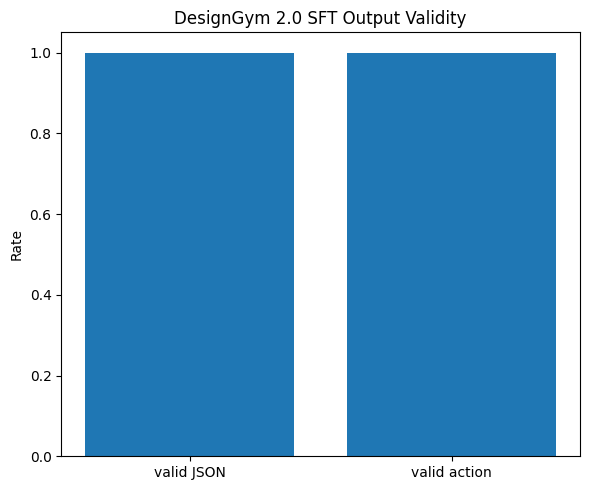

Saved: /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/plots/sft_validity_rates.png


In [22]:
plt.figure(figsize=(6, 5))
plt.bar(["valid JSON", "valid action"], [valid_json_rate, valid_action_rate])
plt.ylim(0, 1.05)
plt.title("DesignGym 2.0 SFT Output Validity")
plt.ylabel("Rate")
plt.tight_layout()

validity_plot_path = PLOT_DIR / "sft_validity_rates.png"
plt.savefig(validity_plot_path, dpi=160)
plt.show()

print("Saved:", validity_plot_path)

In [23]:
for r in rows[:10]:
    print("=" * 80)
    print("TARGET:", r["target"])
    print("GENERATED:", r["generated"])
    print("VALID_JSON:", r["valid_json"], "VALID_ACTION:", r["valid_action"])

TARGET: {"action_type":"resize","anchor":"center","dh":0.02,"dw":0.03,"element_id":"hero_image"}
GENERATED: {"action_type":"resize","anchor":"center","dh":0.02,"dw":0.03,"element_id":"hero_image"}
VALID_JSON: True VALID_ACTION: True
TARGET: {"action_type":"anchor_to_region","element_id":"cta","mode":"center","region_id":"safe_lower_right"}
GENERATED: {"action_type":"anchor_to_region","element_id":"cta","mode":"center","region_id":"safe_lower_right"}
VALID_JSON: True VALID_ACTION: True
TARGET: {"action_type":"resize","anchor":"center","dh":0.01,"dw":0.02,"element_id":"subtitle"}
GENERATED: {"action_type":"resize","anchor":"center","dh":0.02,"dw":0.03,"element_id":"hero_image"}
VALID_JSON: True VALID_ACTION: True
TARGET: {"action_type":"finalize"}
GENERATED: {"action_type":"finalize"}
VALID_JSON: True VALID_ACTION: True
TARGET: {"action_type":"anchor_to_region","element_id":"cta","mode":"center","region_id":"safe_lower_right"}
GENERATED: {"action_type":"anchor_to_region","element_id":"ct

# Uploading SFT adapter to HF Hub

In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [7]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
!find /content/drive/MyDrive/DesignGym2 -name "adapter_config.json" -o -name "adapter_model.safetensors"

/content/drive/MyDrive/DesignGym2/runs/sft_qwen05/trainer_output/checkpoint-400/adapter_model.safetensors
/content/drive/MyDrive/DesignGym2/runs/sft_qwen05/trainer_output/checkpoint-400/adapter_config.json
/content/drive/MyDrive/DesignGym2/runs/sft_qwen05/trainer_output/checkpoint-488/adapter_model.safetensors
/content/drive/MyDrive/DesignGym2/runs/sft_qwen05/trainer_output/checkpoint-488/adapter_config.json
/content/drive/MyDrive/DesignGym2/runs/sft_qwen05/designgym2_sft_qwen05_adapter/adapter_model.safetensors
/content/drive/MyDrive/DesignGym2/runs/sft_qwen05/designgym2_sft_qwen05_adapter/adapter_config.json


In [9]:
from pathlib import Path
from huggingface_hub import HfApi, create_repo, notebook_login

notebook_login()

HF_USERNAME = "yashvyasop"
repo_id = f"{HF_USERNAME}/designgym2-sft-qwen05-lora"

root = Path("/content/drive/MyDrive/DesignGym2")
candidates = list(root.rglob("adapter_config.json"))

print("Found adapter configs:")
for c in candidates:
    print("-", c)

assert candidates, "No adapter_config.json found under /content/drive/MyDrive/DesignGym2"

# Prefer the explicitly saved adapter folder if it exists; otherwise use the latest checkpoint folder.
preferred = [c for c in candidates if "designgym2_sft_qwen05_adapter" in str(c)]
adapter_config = preferred[0] if preferred else candidates[-1]
adapter_dir = adapter_config.parent

print("Using adapter_dir:", adapter_dir)
print("Files:", [p.name for p in adapter_dir.iterdir()])

create_repo(repo_id, repo_type="model", private=False, exist_ok=True)

api = HfApi()
api.upload_folder(
    folder_path=str(adapter_dir),
    repo_id=repo_id,
    repo_type="model",
    commit_message="Upload DesignGym 2.0 SFT Qwen0.5B LoRA adapter",
)

print("Uploaded adapter:", f"https://huggingface.co/{repo_id}")

Found adapter configs:
- /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/designgym2_sft_qwen05_adapter/adapter_config.json
- /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/trainer_output/checkpoint-400/adapter_config.json
- /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/trainer_output/checkpoint-488/adapter_config.json
Using adapter_dir: /content/drive/MyDrive/DesignGym2/runs/sft_qwen05/designgym2_sft_qwen05_adapter
Files: ['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'tokenizer.json']


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...05_adapter/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...adapter_model.safetensors:   0%|          | 38.0kB / 35.2MB            

Uploaded adapter: https://huggingface.co/yashvyasop/designgym2-sft-qwen05-lora


In [10]:
from huggingface_hub import HfApi

repo_id = "yashvyasop/designgym2-sft-qwen05-lora"
files = HfApi().list_repo_files(repo_id, repo_type="model")
files

['.gitattributes',
 'README.md',
 'adapter_config.json',
 'adapter_model.safetensors',
 'chat_template.jinja',
 'tokenizer.json',
 'tokenizer_config.json']